### Installation

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

### Unsloth

In [ ]:
import wandb
from google.colab import userdata
from huggingface_hub import login


hugging_face_token = userdata.get('HF_TOKEN')
wnb_token = userdata.get('wnb')

# Login to Hugging Face
login(hugging_face_token)

# Login to WnB
wandb.login(key=wnb_token) # import wandb
run = wandb.init(
    project='Fine-tune-Qwen3-0.6B-LABD',
    job_type="training"
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: moazeldegwy (moazeldegwy-aou-egypt) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 4096

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-0.6B",
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit = False,
    load_in_8bit = False,
    full_finetuning = False,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.2.1: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

We now add LoRA adapters so we only need to update 1 to 10% of all parameters!

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 64,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 128,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.2.1 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


### Data Prep

In [ ]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "qwen-2.5",
)

In [ ]:
from datasets import load_dataset
from unsloth.chat_templates import standardize_data_formats

# 1. Load
tra_dataset = load_dataset("moazeldegwy/LABD-MBPP", split = "train")
val_dataset = load_dataset("moazeldegwy/LABD-MBPP", split = "validation")

README.md:   0%|          | 0.00/838 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.45M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/294k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/521 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/90 [00:00<?, ? examples/s]

In [ ]:
# 2. Standardize (Fixes keys to 'role', 'content')
tra_dataset = standardize_data_formats(tra_dataset)
val_dataset = standardize_data_formats(val_dataset)

# 4. Inject System Prompt
sys_instruction_xml = """You are an autonomous Self-Correcting Python Agent. Your objective is to produce robust, correct Python code by iteratively generating, testing, and debugging solutions.

### CORE PROTOCOL
You operate in a strictly defined loop: **THOUGHT** -> **ACTION** -> **OBSERVATION**.

1. **THOUGHT (`<think>`):**
   - **Initial Phase:** Analyze the problem requirements, identify edge cases, and formulate a plan.
   - **Debugging Phase:** If previous execution failed, perform a **Forensic Analysis**. You MUST explicitly compare the "Expected" vs "Actual" outputs, identify the **Root Cause** of the logic error, and define a **Fix Strategy**.
   - **Success Phase:** If the previous execution was successful, verify the solution is complete.

2. **ACTION (`<execute>` or Code Block):**
   - **Testing/Debugging:** If the solution is unverified or failed tests, output code inside `<execute>` tags.
     - **CRITICAL:** You MUST append the user-provided `assert` statements (test cases) at the end of the code to verify correctness.
   - **Finalization:** If and ONLY IF the system feedback is "Execution Successful":
     - Output the clean, final solution inside standard Markdown ```python``` tags (without the test assertions).
     - Provide a brief explanation of the code logic after the block.

### STRICT CONSTRAINTS
- **No Hallucination:** Do not simulate `<feedback>` tags. Wait for the system to provide execution results.
- **Evidence-Based:** In debugging, base your fix *strictly* on the error message provided in the feedback.
"""

def add_system_prompt(example):
    conversations = example["conversations"]
    # Qwen supports native system role
    if conversations[0]["role"] != "system":
        conversations.insert(0, {"role": "system", "content": sys_instruction_xml})
    else:
        conversations[0]["content"] = sys_instruction_xml
    return example

# Apply transformations
tra_dataset = tra_dataset.map(add_system_prompt, batched=False)
val_dataset = val_dataset.map(add_system_prompt, batched=False)

# 5. Apply Template
def formatting_prompts_func(examples):
    convos = examples["conversations"]
    texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
    return { "text" : texts, }

tra_dataset = tra_dataset.map(formatting_prompts_func, batched = True)
val_dataset = val_dataset.map(formatting_prompts_func, batched = True)

# --- VERIFICATION ---
# This print should now show <think> tags in the first Assistant message
tra_dataset[0]["text"]

Unsloth: Standardizing formats (num_proc=6):   0%|          | 0/521 [00:00<?, ? examples/s]

Unsloth: Standardizing formats (num_proc=6):   0%|          | 0/90 [00:00<?, ? examples/s]

Map:   0%|          | 0/521 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Map:   0%|          | 0/521 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

'<|im_start|>system\nYou are an autonomous Self-Correcting Python Agent. Your objective is to produce robust, correct Python code by iteratively generating, testing, and debugging solutions.\n\n### CORE PROTOCOL\nYou operate in a strictly defined loop: **THOUGHT** -> **ACTION** -> **OBSERVATION**.\n\n1. **THOUGHT (`<think>`):**\n   - **Initial Phase:** Analyze the problem requirements, identify edge cases, and formulate a plan.\n   - **Debugging Phase:** If previous execution failed, perform a **Forensic Analysis**. You MUST explicitly compare the "Expected" vs "Actual" outputs, identify the **Root Cause** of the logic error, and define a **Fix Strategy**.\n   - **Success Phase:** If the previous execution was successful, verify the solution is complete.\n\n2. **ACTION (`<execute>` or Code Block):**\n   - **Testing/Debugging:** If the solution is unverified or failed tests, output code inside `<execute>` tags.\n     - **CRITICAL:** You MUST append the user-provided `assert` statements 

In [ ]:
# Set your limit (ensure this matches your model loading config)
def count_tokens(examples):
    """
    Tokenizes the formatted 'text' column to calculate the exact token count.
    """
    inputs = tokenizer(examples["text"], add_special_tokens = False)
    return {"length": [len(ids) for ids in inputs["input_ids"]]}

# 1. Calculate lengths for all examples
print("Counting tokens...")
tra_dataset = tra_dataset.map(count_tokens, batched = True)
val_dataset = val_dataset.map(count_tokens, batched = True)

# 2. Print Pre-Filter Statistics
print(f"\n--- Pre-Filter Stats ---")
print(f"Train Size: {len(tra_dataset)}")
print(f"Val Size:   {len(val_dataset)}")

# 3. Apply the Filter
print(f"\nFiltering out examples > {MAX_SEQ_LENGTH} tokens...")
tra_dataset = tra_dataset.filter(lambda x: x["length"] <= MAX_SEQ_LENGTH)
val_dataset = val_dataset.filter(lambda x: x["length"] <= MAX_SEQ_LENGTH)

# 4. Print Post-Filter Statistics
print(f"\n--- Post-Filter Stats ---")
print(f"Train Size: {len(tra_dataset)}")
print(f"Val Size:   {len(val_dataset)}")

Counting tokens...


Map:   0%|          | 0/521 [00:00<?, ? examples/s]

Map:   0%|          | 0/90 [00:00<?, ? examples/s]


--- Pre-Filter Stats ---
Train Size: 521
Val Size:   90

Filtering out examples > 4096 tokens...


Filter:   0%|          | 0/521 [00:00<?, ? examples/s]

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]


--- Post-Filter Stats ---
Train Size: 491
Val Size:   82


### Train the model

In [ ]:
from trl import SFTTrainer, SFTConfig
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = tra_dataset,
    eval_dataset = val_dataset,
    packing = False,
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 32,
        warmup_steps = 10,
        num_train_epochs = 5,
        # max_steps = 30,
        learning_rate = 5e-5,
        logging_steps = 1,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        per_device_eval_batch_size = 1,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        gradient_checkpointing = True,
        report_to = "wandb"
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/491 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/82 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
1.305 GB of memory reserved.


Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 491 | Num Epochs = 5 | Total steps = 80
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 32
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 32 x 1) = 32
 "-____-"     Trainable parameters = 40,370,176 of 636,420,096 (6.34% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,0.709600,0.748340
2,0.587100,0.541138
3,0.512000,0.511059
4,0.525000,0.503199
5,0.495900,0.502021


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


eval/loss,█▂▁▁▁
eval/runtime,█▄▁▂▄
eval/samples_per_second,▁▅█▇▅
eval/steps_per_second,▁▅█▇▅
train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,█▇▅▄▃▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▂▃▅▇█████▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
train/loss,██▇▆▆▄▄▄▄▃▂▂▂▂▂▂▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/loss,0.50202
eval/runtime,99.6097


In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

8672.9233 seconds used for training.
144.55 minutes used for training.
Peak reserved memory = 6.211 GB.
Peak reserved memory for training = 4.906 GB.
Peak reserved memory % of max memory = 42.649 %.
Peak reserved memory for training % of max memory = 33.688 %.


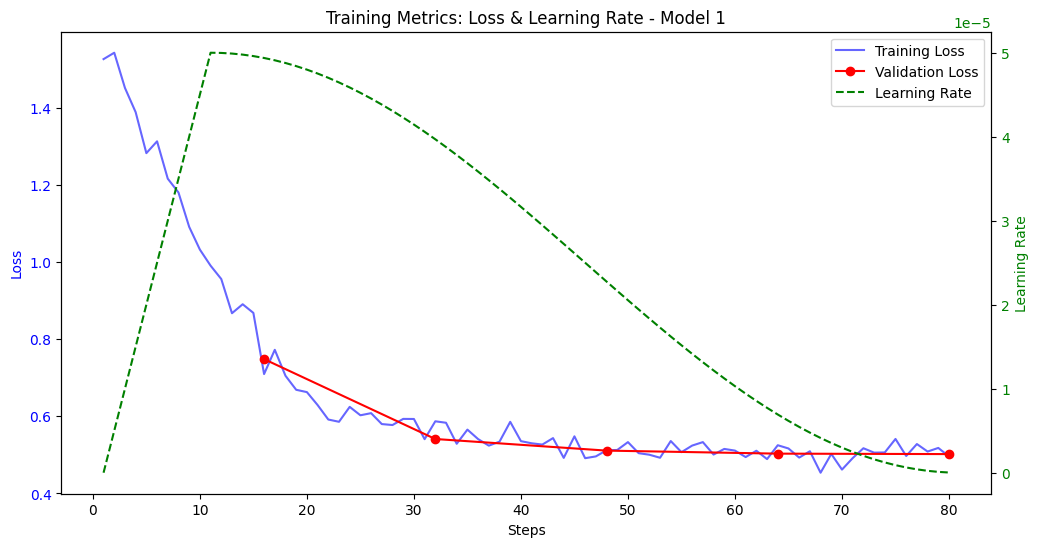

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract the history
history = pd.DataFrame(trainer.state.log_history)

# 2. Setup the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Plot Training Loss ---
# Filter for steps that have training loss
train_data = history.dropna(subset=['loss'])
ax1.plot(train_data['step'], train_data['loss'], label='Training Loss', color='blue', alpha=0.6)
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# --- Plot Validation Loss (If available) ---
if 'eval_loss' in history.columns:
    eval_data = history.dropna(subset=['eval_loss'])
    if not eval_data.empty:
        ax1.plot(eval_data['step'], eval_data['eval_loss'], label='Validation Loss', color='red', marker='o')
    else:
        print("No validation logs found yet.")
else:
    print("Validation loss column not found in history.")

# --- Plot Learning Rate on secondary axis ---
ax2 = ax1.twinx()
# Learning rate is usually logged with training loss
ax2.plot(train_data['step'], train_data['learning_rate'], label='Learning Rate', color='green', linestyle='--')
ax2.set_ylabel('Learning Rate', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Titles and Legends
plt.title('Training Metrics: Loss & Learning Rate - Model 1')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

### Inference

In [ ]:
val_dataset[2]

{'task_id': 513,
 'conversations': [{'content': 'You are an autonomous Self-Correcting Python Agent. Your objective is to produce robust, correct Python code by iteratively generating, testing, and debugging solutions.\n\n### CORE PROTOCOL\nYou operate in a strictly defined loop: **THOUGHT** -> **ACTION** -> **OBSERVATION**.\n\n1. **THOUGHT (`<think>`):**\n   - **Initial Phase:** Analyze the problem requirements, identify edge cases, and formulate a plan.\n   - **Debugging Phase:** If previous execution failed, perform a **Forensic Analysis**. You MUST explicitly compare the "Expected" vs "Actual" outputs, identify the **Root Cause** of the logic error, and define a **Fix Strategy**.\n   - **Success Phase:** If the previous execution was successful, verify the solution is complete.\n\n2. **ACTION (`<execute>` or Code Block):**\n   - **Testing/Debugging:** If the solution is unverified or failed tests, output code inside `<execute>` tags.\n     - **CRITICAL:** You MUST append the user-p

In [ ]:
from transformers import TextStreamer

# 1. Construct the conversation with the System Prompt
messages = [
    {"role": "system", "content": sys_instruction_xml},
    {"role": "user",   "content": "Problem: Write a function to count the element frequency in the mixed nested tuple.\n\nTest Cases:\nassert count_element_freq((5, 6, (5, 6), 7, (8, 9), 9) ) == {5: 2, 6: 2, 7: 1, 8: 1, 9: 2}\nassert count_element_freq((6, 7, (6, 7), 8, (9, 10), 10) ) == {6: 2, 7: 2, 8: 1, 9: 1, 10: 2}\nassert count_element_freq((7, 8, (7, 8), 9, (10, 11), 11) ) == {7: 2, 8: 2, 9: 1, 10: 1, 11: 2}"},
]

# 2. Apply Template (Standard Qwen 2.5)
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True,
)

FastLanguageModel.for_inference(model)

_ = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 4096,
    do_sample = False,
    streamer = TextStreamer(tokenizer, skip_prompt = True),
    stop_strings = ["<|im_end|>", "<|im_start|>"],
    tokenizer = tokenizer,
)

<think>
**Requirements Analysis:**
The task is to write a Python function `count_element_freq` that takes a nested tuple as input. The function must count the frequency of each element within this tuple. The input is a tuple containing both integers and other tuples, which are nested within each other. The function should return a dictionary where the keys are the elements and the values are their respective counts.

**Plan:**
1.  I will define a function `count_element_freq` that accepts a single argument, `nested_tuple`.
2.  I will initialize an empty dictionary, `frequency_dict`, to store the counts.
3.  I will iterate through each element in the `nested_tuple`.
4.  For each element, I will check if it is an integer. If it is, I will increment its count in the `frequency_dict` using `frequency_dict[element] = frequency_dict.get(element, 0) + 1`.
5.  If the element is not an integer, I will recursively call the `count_element_freq` function on the tuple inside it. This recursive call

### Saving finetuned models


In [ ]:
# Push the LoRA adapter to the Hugging Face Hub.
# Replace with your own repo ID before running.
HF_REPO_ID = "moazeldegwy/Qwen3-0.6B-LABD"

model.push_to_hub(HF_REPO_ID)
tokenizer.push_to_hub(HF_REPO_ID)

# To save locally instead, run:
# model.save_pretrained("Qwen3-0.6B-LABD")
# tokenizer.save_pretrained("Qwen3-0.6B-LABD")

In [ ]:
# Merge LoRA weights into the base model and push the 16-bit merged model.
MERGED_REPO_ID = "moazeldegwy/Qwen3-0.6B-LABD-merged"

model.push_to_hub_merged(
    MERGED_REPO_ID,
    tokenizer,
    save_method = "merged_16bit",
    token = hugging_face_token,
)